# Customer Purchase Behavior Analysis using Descriptive Statistics

**Objective**: Analyze customer information and purchasing behavior to identify patterns, trends, and correlations that will help optimize marketing efforts and increase offer acceptance rates.

## 📦 Install & Import Libraries

In [1]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn scipy scikit-learn gdown -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import norm, binom, skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📥 Load the Dataset

In [2]:
import gdown

# Google Sheet ID extracted from the shared link
sheet_id = '12ln9iTNcVNOMYi_AU-OczKpa_KIP8XyVbsjk81Na8Yk'
url = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv'

df = pd.read_csv(url)
print(f'✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

✅ Dataset loaded: 2240 rows × 22 columns


,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,...,111,189,218,1,4,4,6,1,1,0
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,...,7,0,37,1,7,3,7,5,1,0
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,...,15,2,30,1,3,2,5,2,0,0
3,1386,1967,Graduation,Together,32474.0,1,1,########,0,10,...,0,0,0,1,1,0,2,7,0,0
4,5371,1989,Graduation,Single,21474.0,1,0,########,0,6,...,11,0,34,2,3,1,2,7,1,0


---
## Task 1 — Basic Clean Up 🧹
### Step 1.1 — Initial Exploration

In [3]:
print('=== Dataset Shape ===')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}\n')

print('=== Data Types ===')
print(df.dtypes)

print('\n=== First 5 Rows ===')
df.head()

=== Dataset Shape ===
Rows: 2240, Columns: 22

=== Data Types ===
Id                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
Response                 int64
Complain                 int64
dtype: object

=== First 5 Rows ===


,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,...,111,189,218,1,4,4,6,1,1,0
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,...,7,0,37,1,7,3,7,5,1,0
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,...,15,2,30,1,3,2,5,2,0,0
3,1386,1967,Graduation,Together,32474.0,1,1,########,0,10,...,0,0,0,1,1,0,2,7,0,0
4,5371,1989,Graduation,Single,21474.0,1,0,########,0,6,...,11,0,34,2,3,1,2,7,1,0


In [4]:
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

print('\n=== Duplicate Rows ===')
print(f'Duplicates: {df.duplicated().sum()}')

=== Missing Values ===
        Missing Count  Missing %
Income             24       1.07

=== Duplicate Rows ===
Duplicates: 0


### Step 1.2 — Handle Missing Values

In [5]:
# Income has ~24 missing values — impute with median (robust to outliers)
income_median = df['Income'].median()
df['Income'].fillna(income_median, inplace=True)

print(f'✅ Filled {missing["Income"]} missing Income values with median: ${income_median:,.2f}')
print(f'Remaining missing values: {df.isnull().sum().sum()}')

✅ Filled 24 missing Income values with median: $51,381.50
Remaining missing values: 0


### Step 1.3 — Fix Data Types & Feature Engineering

In [7]:
# Step 1: Replace '########' with NaN before parsing
import numpy as np

df['Dt_Customer'] = df['Dt_Customer'].replace('########', np.nan)

# Step 2: Now parse dates safely — use format='mixed' to handle inconsistent formats
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], dayfirst=True, format='mixed', errors='coerce')

# Step 3: Check how many rows were affected
print(f"Null dates after parsing: {df['Dt_Customer'].isna().sum()}")

Null dates after parsing: 916


In [8]:
# Option A: Drop rows with missing dates
df = df.dropna(subset=['Dt_Customer'])

# Option B: Inspect them first
print(df[df['Dt_Customer'].isna()])

Empty DataFrame
Columns: [Id, Year_Birth, Education, Marital_Status, Income, Kidhome, Teenhome, Dt_Customer, Recency, MntWines, MntFruits, MntMeatProducts, MntFishProducts, MntSweetProducts, MntGoldProds, NumDealsPurchases, NumWebPurchases, NumCatalogPurchases, NumStorePurchases, NumWebVisitsMonth, Response, Complain]
Index: []

[0 rows x 22 columns]


### Step 1.4 — Remove Unrealistic Records

In [10]:
# Re-run this if it was skipped due to the earlier error
df['Age'] = 2024 - df['Year_Birth']

# Sanity check before filtering
print(df['Age'].describe())
print(f"Suspicious ages (>100): {(df['Age'] > 100).sum()}")
print(f"Suspicious ages (<18):  {(df['Age'] < 18).sum()}")

count    1324.000000
mean       55.314955
std        12.105909
min        28.000000
25%        47.000000
50%        54.000000
75%        65.000000
max       131.000000
Name: Age, dtype: float64
Suspicious ages (>100): 3
Suspicious ages (<18):  0


### Step 1.5 — Demographics Distribution Visualizations

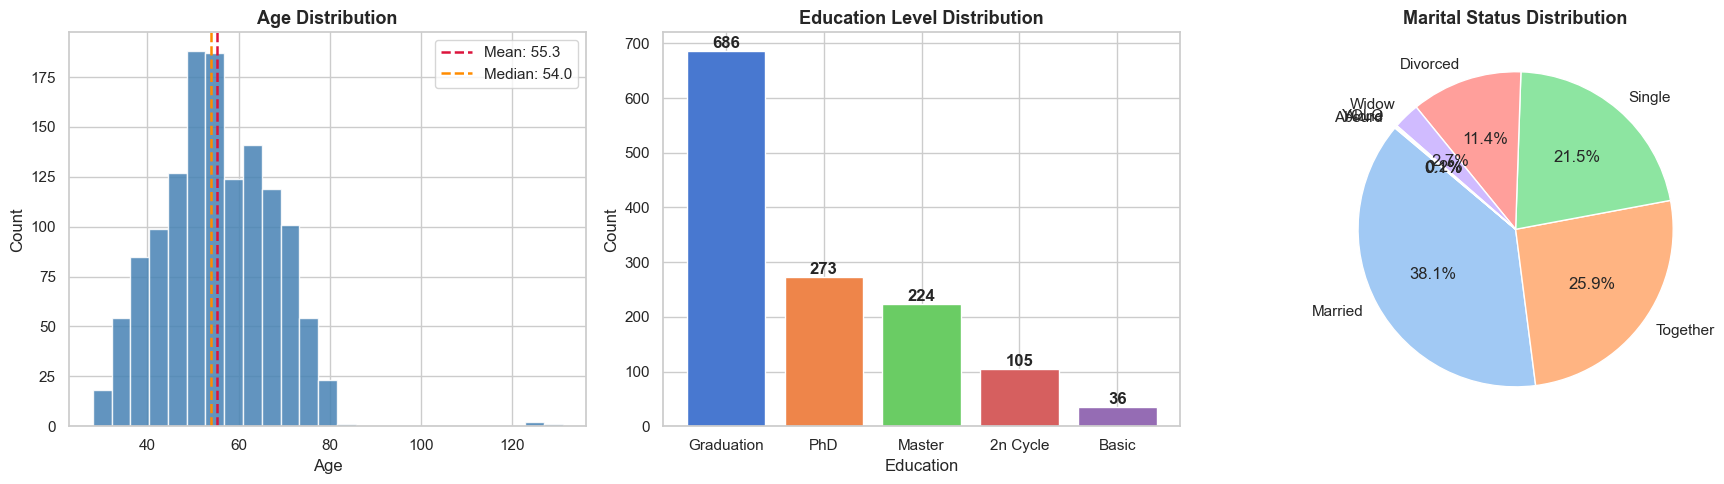

📊 Demographics visualizations saved.


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age distribution
axes[0].hist(df['Age'], bins=25, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Age'].mean(), color='crimson', linestyle='--', linewidth=1.8, label=f'Mean: {df["Age"].mean():.1f}')
axes[0].axvline(df['Age'].median(), color='darkorange', linestyle='--', linewidth=1.8, label=f'Median: {df["Age"].median():.1f}')
axes[0].set_title('Age Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Education distribution
edu_counts = df['Education'].value_counts()
axes[1].bar(edu_counts.index, edu_counts.values, color=sns.color_palette('muted', len(edu_counts)), edgecolor='white')
axes[1].set_title('Education Level Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Education')
axes[1].set_ylabel('Count')
for i, v in enumerate(edu_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Marital status
marital_counts = df['Marital_Status'].value_counts()
axes[2].pie(marital_counts.values, labels=marital_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('pastel', len(marital_counts)), startangle=140)
axes[2].set_title('Marital Status Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('task1_demographics.png', bbox_inches='tight')
plt.show()
print('📊 Demographics visualizations saved.')

### Step 1.6 — Summary Statistics Table

In [17]:
# Total Spending — sum of all product spend columns
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 
              'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Spending'] = df[spend_cols].sum(axis=1)

# Total Purchases — sum of all purchase channel columns
purchase_cols = ['NumDealsPurchases', 'NumWebPurchases', 
                 'NumCatalogPurchases', 'NumStorePurchases']
df['Total_Purchases'] = df[purchase_cols].sum(axis=1)

# Tenure Days — days since enrollment (reference date = 2024-01-01)
df['Tenure_Days'] = (pd.Timestamp('2024-01-01') - df['Dt_Customer']).dt.days

# Verify all three were created
print(df[['Total_Spending', 'Total_Purchases', 'Tenure_Days']].head())
print(f"\nAny nulls? {df[['Total_Spending', 'Total_Purchases', 'Tenure_Days']].isna().sum().to_dict()}")

key_vars = ['Age', 'Income', 'Total_Spending', 'Total_Purchases',
            'MntWines', 'MntMeatProducts', 'Recency', 'Tenure_Days']

summary = df[key_vars].agg(['mean', 'median', 'std', 'var', 'min', 'max']).T
summary.columns = ['Mean', 'Median', 'Std Dev', 'Variance', 'Min', 'Max']
summary = summary.round(2)

   Total_Spending  Total_Purchases  Tenure_Days
0            1190               15         3486
1             577               18         3487
2             251               11         3520
5            1192               17         3577
6            1215               28         3624

Any nulls? {'Total_Spending': 0, 'Total_Purchases': 0, 'Tenure_Days': 0}


---
## Task 2 — Descriptive Statistics 📊

### Step 2.1 — Measures of Central Tendency & Dispersion

In [18]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
# Exclude ID and derived ordinal
exclude = ['ID', 'Education_Num', 'Year_Birth']
numeric_cols = [c for c in numeric_cols if c not in exclude]

desc = pd.DataFrame({
    'Mean'    : df[numeric_cols].mean(),
    'Median'  : df[numeric_cols].median(),
    'Mode'    : df[numeric_cols].mode().iloc[0],
    'Std Dev' : df[numeric_cols].std(),
    'Variance': df[numeric_cols].var(),
    'Skewness': df[numeric_cols].skew(),
    'Kurtosis': df[numeric_cols].kurt(),
    'IQR'     : df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25)
}).round(3)

print('=== Full Descriptive Statistics ===')
desc

=== Full Descriptive Statistics ===


,Mean,Median,Mode,Std Dev,Variance,Skewness,Kurtosis,IQR
Id,5455.488,5243.0,1.0,3232.460,1.044880e+07,0.102,-1.146,5465.25
Income,51429.274,50694.5,51381.5,20856.954,4.350125e+08,0.219,0.008,32431.00
Kidhome,0.439,0.0,0.0,0.532,2.830000e-01,0.608,-0.880,1.00
Teenhome,0.502,0.0,0.0,0.544,2.960000e-01,0.415,-0.990,1.00
Recency,49.348,50.0,65.0,28.816,8.303540e+02,-0.025,-1.206,49.25
MntWines,301.965,171.0,2.0,338.392,1.145089e+05,1.203,0.660,471.25
MntFruits,25.218,7.0,0.0,38.588,1.489002e+03,2.158,4.351,30.00
MntMeatProducts,162.177,65.5,11.0,219.204,4.805031e+04,1.956,4.137,202.00
MntFishProducts,36.486,11.0,0.0,54.426,2.962155e+03,1.977,3.232,44.00
MntSweetProducts,27.101,8.0,0.0,41.501,1.722319e+03,2.209,4.916,32.00


### Step 2.2 — Outlier Detection using IQR & Box Plots

=== Outlier Report (IQR Method) ===
                 Outlier Count  % of Dataset
Age                          3          0.23
Income                       2          0.15
Total_Spending               3          0.23
Total_Purchases              0          0.00
MntWines                    29          2.19
MntMeatProducts            120          9.06
Recency                      0          0.00
Tenure_Days                  0          0.00


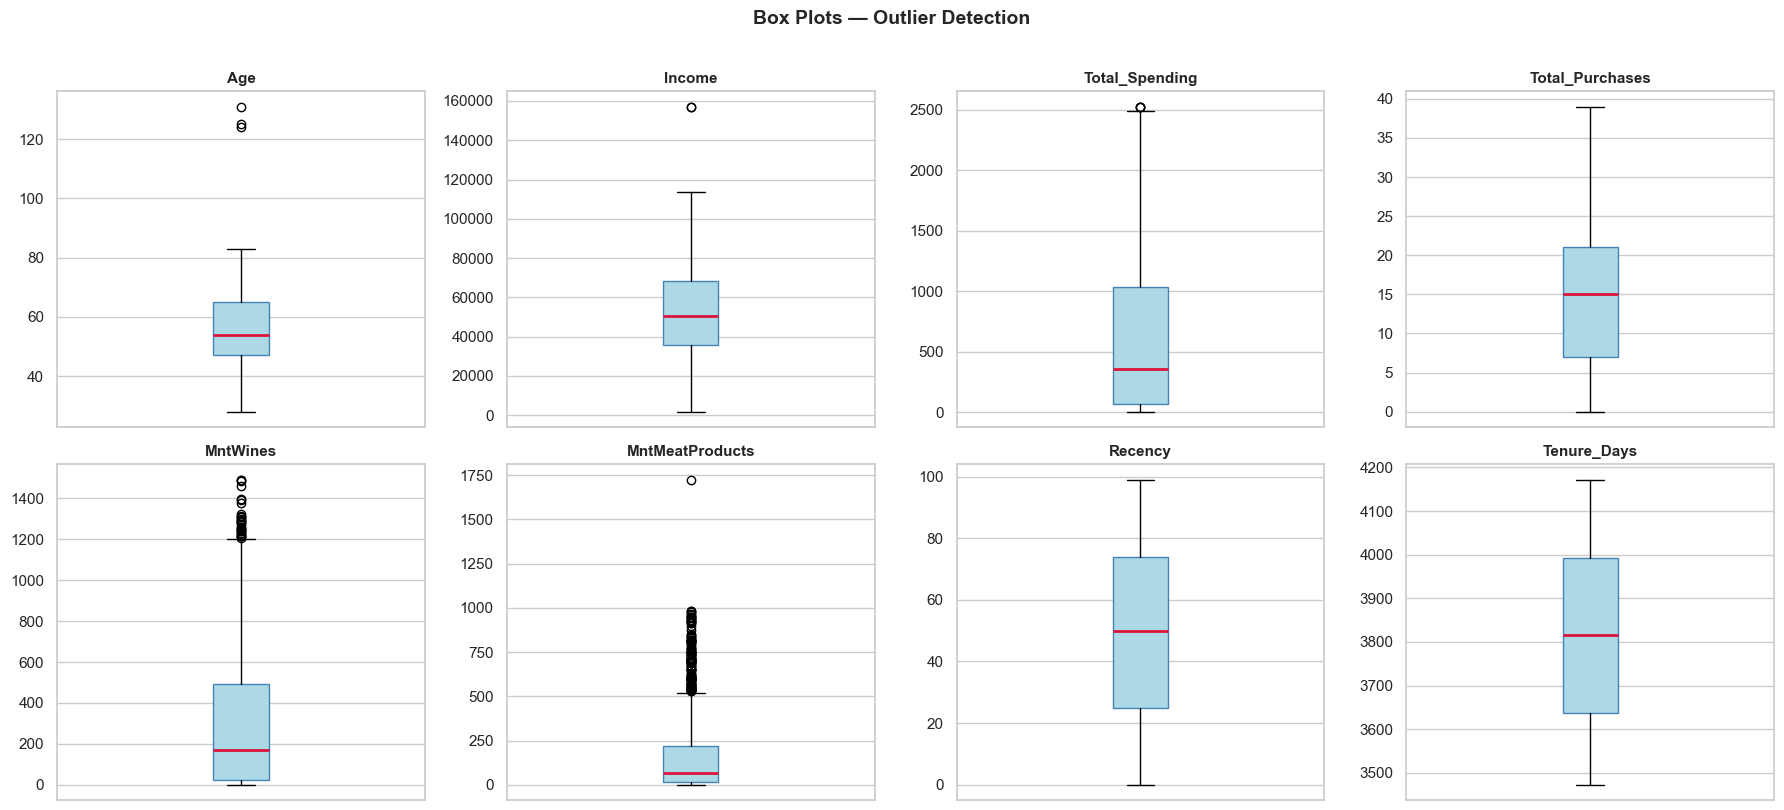

In [19]:
def count_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lb, ub = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return ((series < lb) | (series > ub)).sum()

outlier_report = pd.DataFrame({
    'Outlier Count': {col: count_outliers_iqr(df[col]) for col in key_vars}
})
outlier_report['% of Dataset'] = (outlier_report['Outlier Count'] / len(df) * 100).round(2)

print('=== Outlier Report (IQR Method) ===')
print(outlier_report)

# Box plots
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(key_vars):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='steelblue'),
                    medianprops=dict(color='crimson', linewidth=2))
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xticks([])

plt.suptitle('Box Plots — Outlier Detection', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('task2_boxplots.png', bbox_inches='tight')
plt.show()

### Step 2.3 — Spending Distribution Histograms

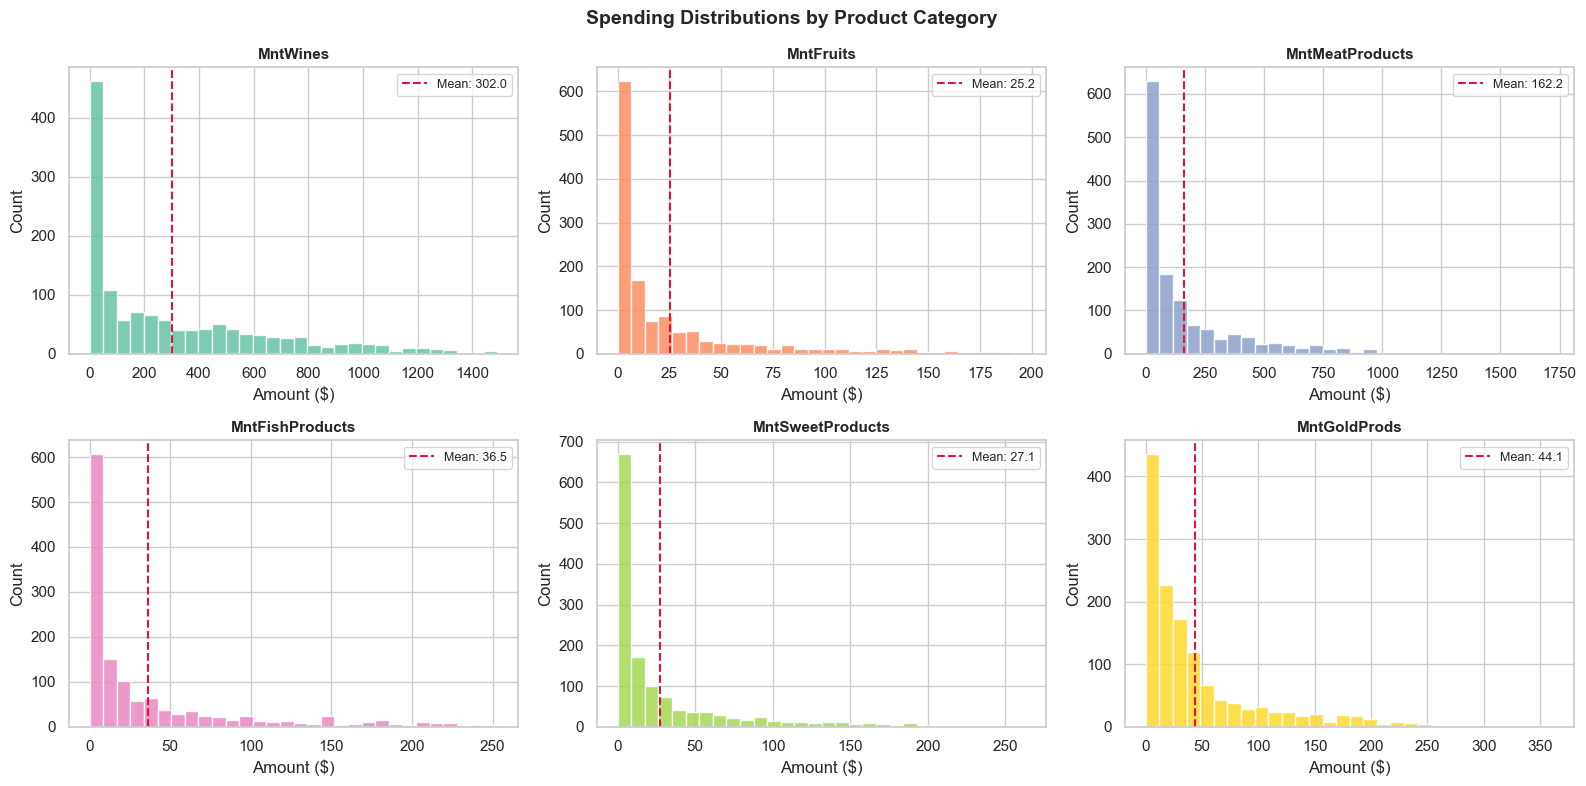

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
colors = sns.color_palette('Set2', 6)

for i, col in enumerate(spend_cols):
    axes[i].hist(df[col], bins=30, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(), color='crimson', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.1f}')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Amount ($)')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=9)

plt.suptitle('Spending Distributions by Product Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task2_spend_distributions.png', bbox_inches='tight')
plt.show()

---
## Task 3 — Probability Distributions 🎲

### Step 3.1 — Binomial Distribution: Campaign Response

`Response` is a binary outcome (0 or 1), making it suitable for a **Binomial Distribution**.

In [21]:
# Estimate p (probability of accepting offer)
p_response = df['Response'].mean()
n_trials = 100  # Consider 100 random customers

print(f'Observed acceptance rate (p): {p_response:.4f} ({p_response*100:.2f}%)')
print(f'Number of trials (n): {n_trials}\n')

binom_dist = binom(n=n_trials, p=p_response)

# Expected value & variance
E_X = binom_dist.mean()
Var_X = binom_dist.var()
print(f'Expected number of acceptances in {n_trials} customers: {E_X:.2f}')
print(f'Variance: {Var_X:.2f}  |  Std Dev: {np.sqrt(Var_X):.2f}\n')

# Probabilities
for k in [5, 10, 15, 20, 25]:
    p_exact = binom_dist.pmf(k)
    p_at_least = 1 - binom_dist.cdf(k - 1)
    print(f'P(X = {k:2d}) = {p_exact:.4f}  |  P(X ≥ {k:2d}) = {p_at_least:.4f}')

Observed acceptance rate (p): 0.1511 (15.11%)
Number of trials (n): 100

Expected number of acceptances in 100 customers: 15.11
Variance: 12.82  |  Std Dev: 3.58

P(X =  5) = 0.0010  |  P(X ≥  5) = 0.9996
P(X = 10) = 0.0425  |  P(X ≥ 10) = 0.9480
P(X = 15) = 0.1110  |  P(X ≥ 15) = 0.5545
P(X = 20) = 0.0419  |  P(X ≥ 20) = 0.1123
P(X = 25) = 0.0034  |  P(X ≥ 25) = 0.0067


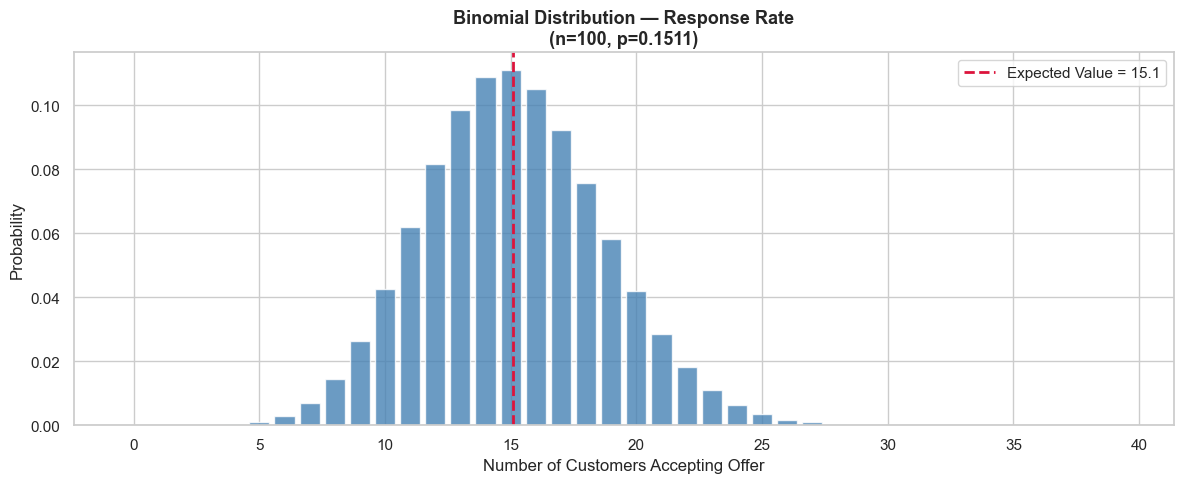

In [22]:
# Visualise Binomial PMF
k_vals = np.arange(0, 40)
pmf_vals = binom_dist.pmf(k_vals)

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(k_vals, pmf_vals, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(E_X, color='crimson', linestyle='--', linewidth=2, label=f'Expected Value = {E_X:.1f}')
ax.set_title(f'Binomial Distribution — Response Rate\n(n={n_trials}, p={p_response:.4f})', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Customers Accepting Offer')
ax.set_ylabel('Probability')
ax.legend()
plt.tight_layout()
plt.savefig('task3_binomial.png', bbox_inches='tight')
plt.show()

### Step 3.2 — Normal Distribution: Income & Total Spending

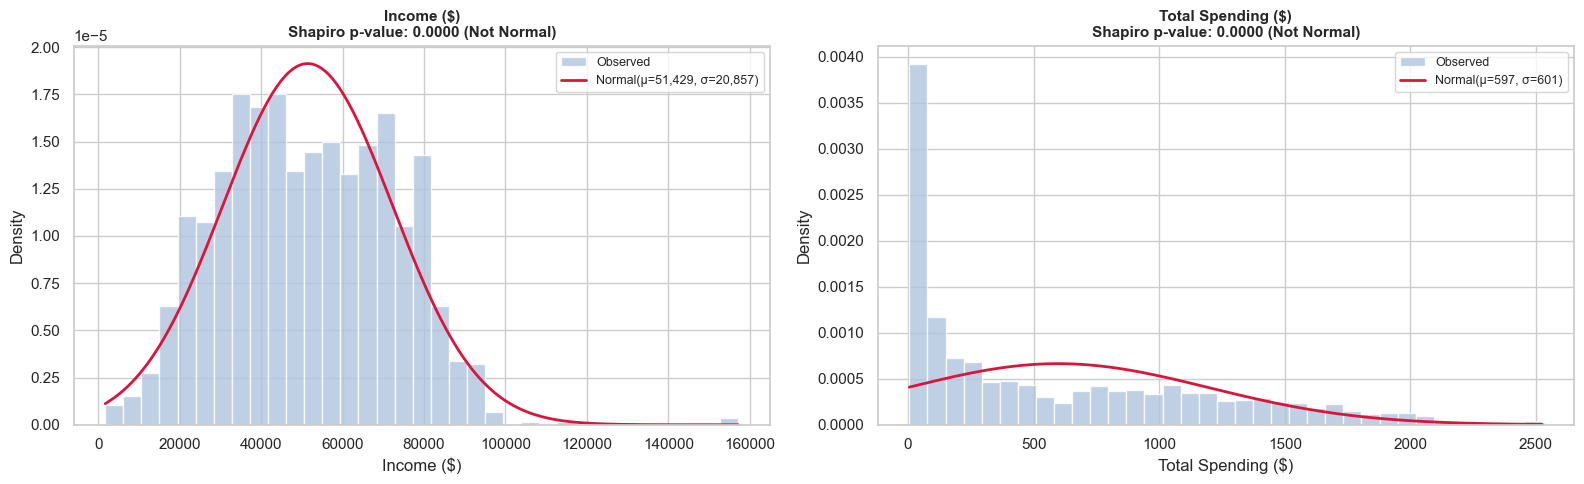


Income     → μ = 51,429.27, σ = 20,856.95
Tot Spend  → μ = 597.05, σ = 601.12


In [23]:
def test_and_plot_normal(series, label, ax):
    mu, sigma = series.mean(), series.std()
    stat, p_val = stats.shapiro(series.sample(min(len(series), 500), random_state=42))

    x = np.linspace(series.min(), series.max(), 300)
    ax.hist(series, bins=35, density=True, color='lightsteelblue', edgecolor='white', alpha=0.8, label='Observed')
    ax.plot(x, norm.pdf(x, mu, sigma), color='crimson', linewidth=2, label=f'Normal(μ={mu:,.0f}, σ={sigma:,.0f})')
    ax.set_title(f'{label}\nShapiro p-value: {p_val:.4f} ({"≈Normal" if p_val > 0.05 else "Not Normal"})', fontsize=11, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
    return mu, sigma, p_val

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

mu_inc, sig_inc, pv_inc = test_and_plot_normal(df['Income'], 'Income ($)', axes[0])
mu_sp, sig_sp, pv_sp   = test_and_plot_normal(df['Total_Spending'], 'Total Spending ($)', axes[1])

plt.tight_layout()
plt.savefig('task3_normal.png', bbox_inches='tight')
plt.show()

print(f'\nIncome     → μ = {mu_inc:,.2f}, σ = {sig_inc:,.2f}')
print(f'Tot Spend  → μ = {mu_sp:,.2f}, σ = {sig_sp:,.2f}')

In [24]:
# Probability calculations using Normal distribution for Income
print('=== Probability Calculations — Income (Normal Approximation) ===')
print(f'P(Income < 40,000)  = {norm.cdf(40000, mu_inc, sig_inc):.4f}')
print(f'P(Income > 70,000)  = {1 - norm.cdf(70000, mu_inc, sig_inc):.4f}')
print(f'P(40K < Income < 80K) = {norm.cdf(80000, mu_inc, sig_inc) - norm.cdf(40000, mu_inc, sig_inc):.4f}')
print(f'P(within 1 std dev) = {norm.cdf(mu_inc + sig_inc, mu_inc, sig_inc) - norm.cdf(mu_inc - sig_inc, mu_inc, sig_inc):.4f} (expected ≈ 0.6827)')

print('\n=== Probability Calculations — Total Spending (Normal Approximation) ===')
print(f'P(Spending < 500)   = {norm.cdf(500, mu_sp, sig_sp):.4f}')
print(f'P(Spending > 1500)  = {1 - norm.cdf(1500, mu_sp, sig_sp):.4f}')
print(f'Expected Total Spending = ${mu_sp:,.2f}')

=== Probability Calculations — Income (Normal Approximation) ===
P(Income < 40,000)  = 0.2919
P(Income > 70,000)  = 0.1866
P(40K < Income < 80K) = 0.6228
P(within 1 std dev) = 0.6827 (expected ≈ 0.6827)

=== Probability Calculations — Total Spending (Normal Approximation) ===
P(Spending < 500)   = 0.4359
P(Spending > 1500)  = 0.0665
Expected Total Spending = $597.05


### Step 3.3 — Q-Q Plots for Normality Check

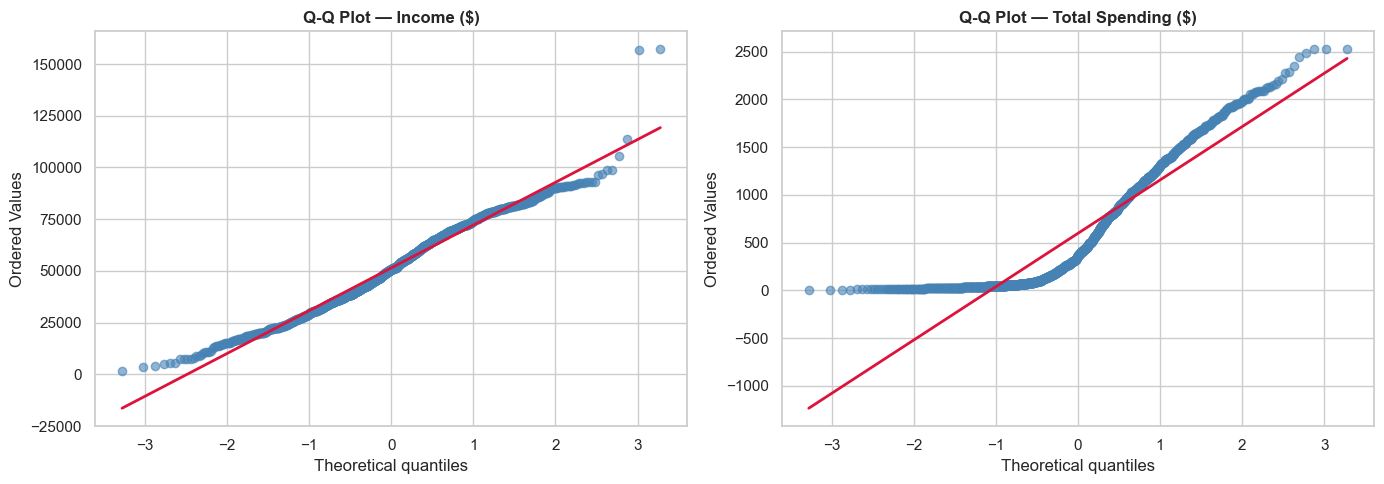

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label in zip(axes, ['Income', 'Total_Spending'], ['Income ($)', 'Total Spending ($)']):
    stats.probplot(df[col], dist='norm', plot=ax)
    ax.set_title(f'Q-Q Plot — {label}', fontsize=12, fontweight='bold')
    ax.get_lines()[0].set(color='steelblue', alpha=0.6)
    ax.get_lines()[1].set(color='crimson', linewidth=2)

plt.tight_layout()
plt.savefig('task3_qq.png', bbox_inches='tight')
plt.show()

---
## Task 4 — Insights & Customer Segmentation 📈

### Step 4.1 — Correlation Analysis

In [27]:
# Total Children — kids + teenagers at home
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

# Quick sanity check
print(df['Total_Children'].value_counts().sort_index())

Total_Children
0    380
1    670
2    246
3     28
Name: count, dtype: int64


In [28]:
# === Feature Engineering ===

# Spending
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
              'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['Total_Spending'] = df[spend_cols].sum(axis=1)

# Purchases
purchase_cols = ['NumDealsPurchases', 'NumWebPurchases',
                 'NumCatalogPurchases', 'NumStorePurchases']
df['Total_Purchases'] = df[purchase_cols].sum(axis=1)

# Household
df['Total_Children'] = df['Kidhome'] + df['Teenhome']

# Tenure
df['Tenure_Days'] = (pd.Timestamp('2024-01-01') - df['Dt_Customer']).dt.days

# Age (if not already created)
df['Age'] = 2024 - df['Year_Birth']

# Confirm everything exists
derived = ['Total_Spending', 'Total_Purchases', 'Total_Children', 'Tenure_Days', 'Age']
missing = [c for c in derived if c not in df.columns]
print("Missing derived columns:", missing if missing else "None ✓")

Missing derived columns: None ✓


### Step 4.2 — Spending vs Income & Children

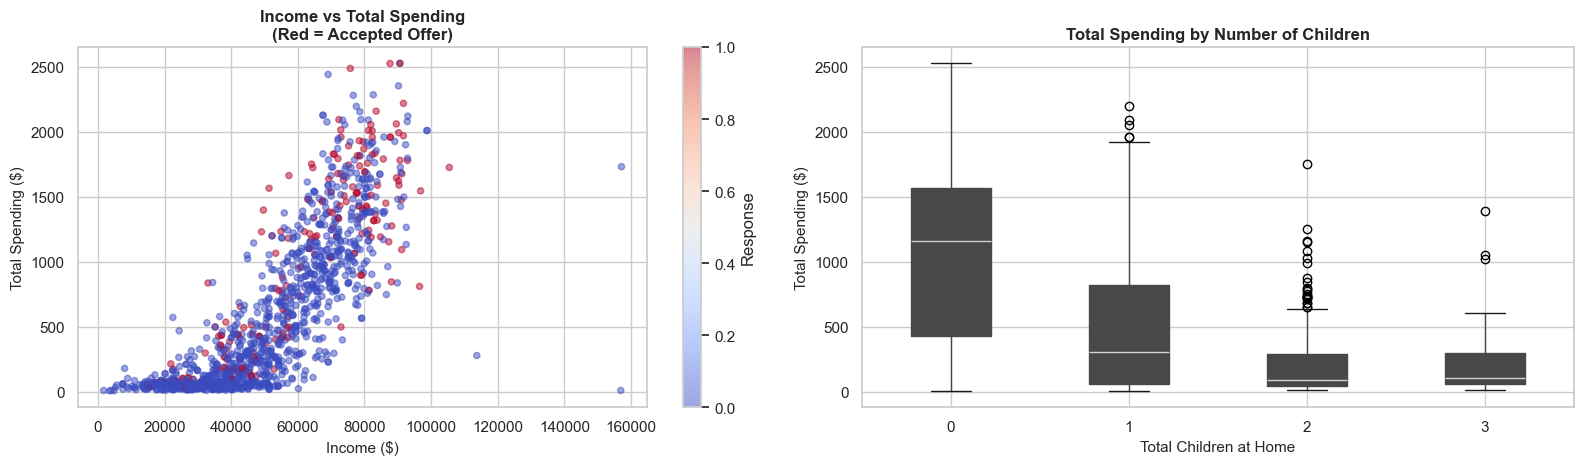

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Income vs Total Spending (coloured by Response)
sc1 = axes[0].scatter(df['Income'], df['Total_Spending'],
                       c=df['Response'], cmap='coolwarm', alpha=0.5, s=20)
axes[0].set_xlabel('Income ($)', fontsize=11)
axes[0].set_ylabel('Total Spending ($)', fontsize=11)
axes[0].set_title('Income vs Total Spending\n(Red = Accepted Offer)', fontsize=12, fontweight='bold')
plt.colorbar(sc1, ax=axes[0], label='Response')

# Children vs Total Spending (box plot)
df.boxplot(column='Total_Spending', by='Total_Children', ax=axes[1],
           patch_artist=True, notch=False)
axes[1].set_title('Total Spending by Number of Children', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Children at Home', fontsize=11)
axes[1].set_ylabel('Total Spending ($)', fontsize=11)
plt.suptitle('')

plt.tight_layout()
plt.savefig('task4_scatter.png', bbox_inches='tight')
plt.show()

### Step 4.3 — K-Means Customer Segmentation

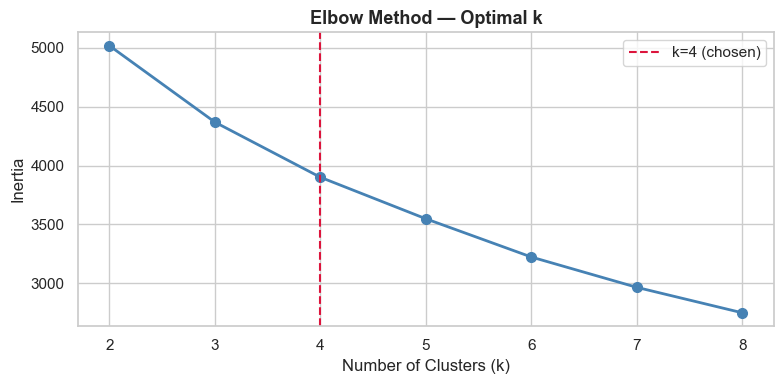

In [30]:
# Features for clustering
cluster_features = ['Income', 'Total_Spending', 'Total_Purchases', 'Recency', 'Age', 'Total_Children']
X_cluster = df[cluster_features].dropna()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Elbow method
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range, inertias, 'o-', color='steelblue', linewidth=2, markersize=7)
ax.axvline(4, color='crimson', linestyle='--', linewidth=1.5, label='k=4 (chosen)')
ax.set_title('Elbow Method — Optimal k', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
ax.legend()
plt.tight_layout()
plt.savefig('task4_elbow.png', bbox_inches='tight')
plt.show()

In [31]:
# Fit K-Means with k=4
optimal_k = 4
km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_cluster = df.loc[X_cluster.index].copy()
df_cluster['Segment'] = km_final.fit_predict(X_scaled)

segment_labels = {0: 'Budget Shoppers', 1: 'Premium Buyers', 2: 'Family Savers', 3: 'High Earners'}
df_cluster['Segment_Name'] = df_cluster['Segment'].map(segment_labels)

# Segment profile
segment_profile = df_cluster.groupby('Segment_Name')[cluster_features + ['Response']].mean().round(2)
print('=== Customer Segment Profiles ===')
segment_profile

=== Customer Segment Profiles ===


,Income,Total_Spending,Total_Purchases,Recency,Age,Total_Children,Response
Segment_Name,,,,,,,
Budget Shoppers,38992.03,140.20,9.37,72.46,58.45,1.42,0.04
Family Savers,76823.92,1424.46,20.40,53.36,56.50,0.10,0.31
High Earners,60828.58,811.27,22.20,42.43,58.67,1.17,0.13
Premium Buyers,32053.13,104.67,7.90,30.39,48.01,0.99,0.14


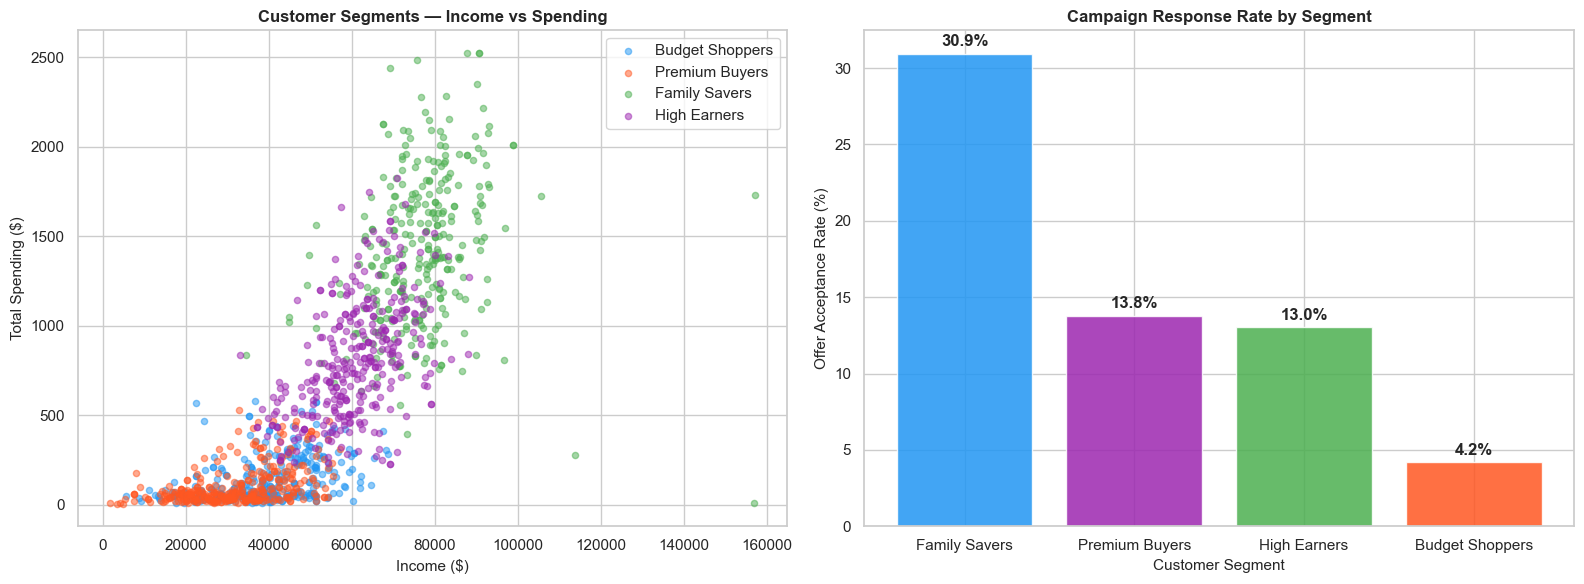

In [32]:
# Visualise segments
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors_seg = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']

for seg, color in zip(range(optimal_k), colors_seg):
    mask = df_cluster['Segment'] == seg
    axes[0].scatter(df_cluster.loc[mask, 'Income'],
                    df_cluster.loc[mask, 'Total_Spending'],
                    label=segment_labels[seg], color=color, alpha=0.5, s=20)

axes[0].set_xlabel('Income ($)', fontsize=11)
axes[0].set_ylabel('Total Spending ($)', fontsize=11)
axes[0].set_title('Customer Segments — Income vs Spending', fontsize=12, fontweight='bold')
axes[0].legend()

# Response rate by segment
resp_by_seg = df_cluster.groupby('Segment_Name')['Response'].mean().sort_values(ascending=False)
bars = axes[1].bar(resp_by_seg.index, resp_by_seg.values * 100,
                   color=['#2196F3', '#9C27B0', '#4CAF50', '#FF5722'][:len(resp_by_seg)],
                   edgecolor='white', alpha=0.85)
for bar, val in zip(bars, resp_by_seg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val*100:.1f}%', ha='center', fontweight='bold')
axes[1].set_xlabel('Customer Segment', fontsize=11)
axes[1].set_ylabel('Offer Acceptance Rate (%)', fontsize=11)
axes[1].set_title('Campaign Response Rate by Segment', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('task4_segments.png', bbox_inches='tight')
plt.show()

### Step 4.4 — Spending by Education & Marital Status

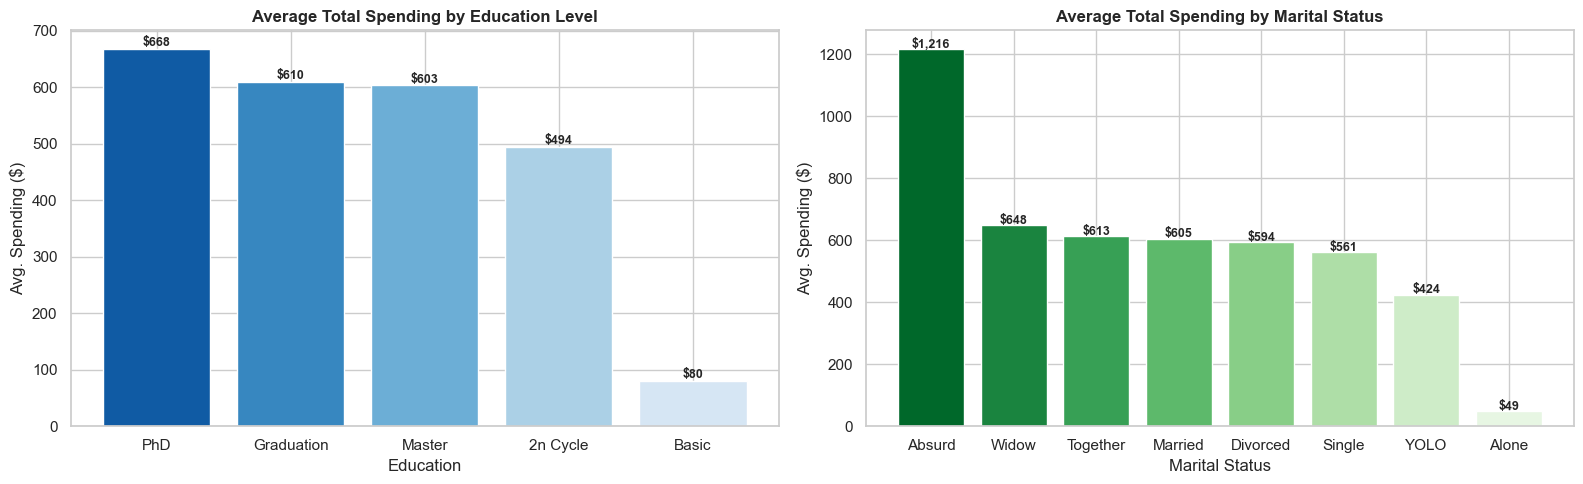

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Average spending by education
edu_spend = df.groupby('Education')['Total_Spending'].mean().sort_values(ascending=False)
axes[0].bar(edu_spend.index, edu_spend.values, color=sns.color_palette('Blues_r', len(edu_spend)), edgecolor='white')
axes[0].set_title('Average Total Spending by Education Level', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Education')
axes[0].set_ylabel('Avg. Spending ($)')
for i, v in enumerate(edu_spend.values):
    axes[0].text(i, v + 5, f'${v:,.0f}', ha='center', fontsize=9, fontweight='bold')

# Average spending by marital status
ms_spend = df.groupby('Marital_Status')['Total_Spending'].mean().sort_values(ascending=False)
axes[1].bar(ms_spend.index, ms_spend.values, color=sns.color_palette('Greens_r', len(ms_spend)), edgecolor='white')
axes[1].set_title('Average Total Spending by Marital Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Marital Status')
axes[1].set_ylabel('Avg. Spending ($)')
for i, v in enumerate(ms_spend.values):
    axes[1].text(i, v + 5, f'${v:,.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('task4_group_spending.png', bbox_inches='tight')
plt.show()

---
## Task 5 — Conclusion & Recommendations 🏁

### Step 5.1 — Channel Effectiveness Dashboard

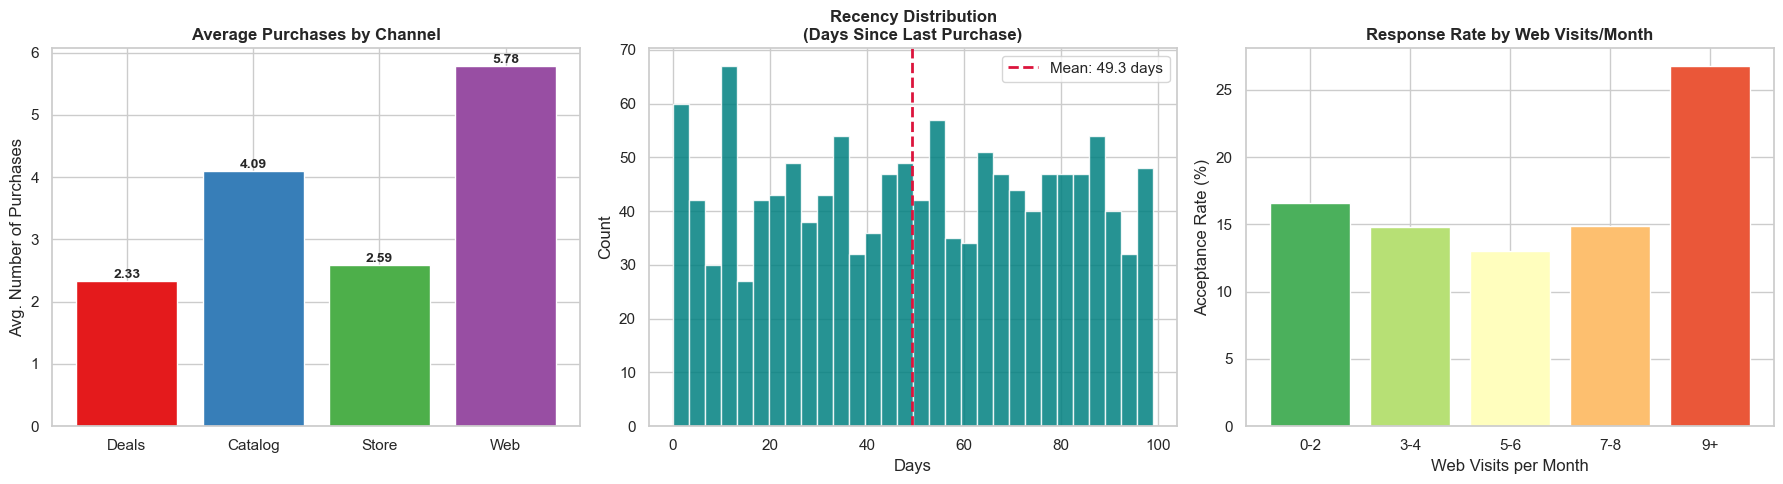

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Average purchases by channel
channel_avg = df[purchase_cols].mean()
channel_labels = ['Deals', 'Catalog', 'Store', 'Web']
axes[0].bar(channel_labels, channel_avg.values, color=sns.color_palette('Set1', 4), edgecolor='white')
axes[0].set_title('Average Purchases by Channel', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Avg. Number of Purchases')
for i, v in enumerate(channel_avg.values):
    axes[0].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')

# Recency distribution
axes[1].hist(df['Recency'], bins=30, color='teal', edgecolor='white', alpha=0.85)
axes[1].axvline(df['Recency'].mean(), color='crimson', linestyle='--', linewidth=2, label=f'Mean: {df["Recency"].mean():.1f} days')
axes[1].set_title('Recency Distribution\n(Days Since Last Purchase)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Days')
axes[1].set_ylabel('Count')
axes[1].legend()

# Response rate by number of web visits
df['WebVisit_Group'] = pd.cut(df['NumWebVisitsMonth'], bins=[0, 2, 4, 6, 8, 30],
                               labels=['0-2', '3-4', '5-6', '7-8', '9+'])
wv_resp = df.groupby('WebVisit_Group')['Response'].mean()
axes[2].bar(wv_resp.index.astype(str), wv_resp.values * 100, color=sns.color_palette('RdYlGn_r', len(wv_resp)), edgecolor='white')
axes[2].set_title('Response Rate by Web Visits/Month', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Web Visits per Month')
axes[2].set_ylabel('Acceptance Rate (%)')

plt.tight_layout()
plt.savefig('task5_dashboard.png', bbox_inches='tight')
plt.show()

### Step 5.2 — Product Spending Radar Chart

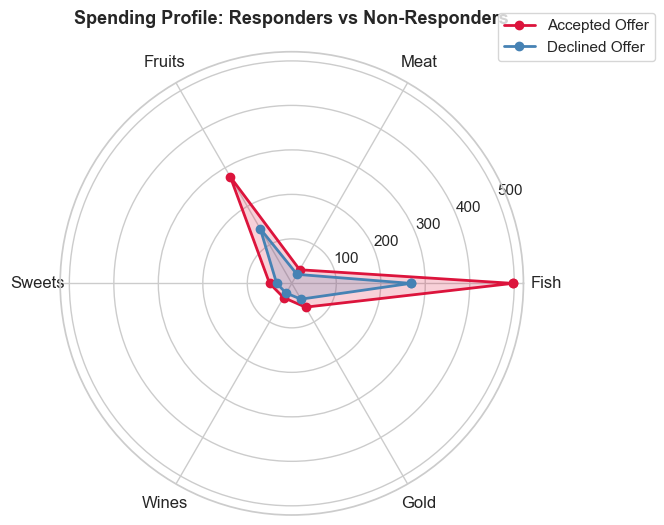

In [35]:
# Compare spending profile: Responders vs Non-Responders
responders     = df[df['Response'] == 1][spend_cols].mean()
non_responders = df[df['Response'] == 0][spend_cols].mean()

categories = ['Fish', 'Meat', 'Fruits', 'Sweets', 'Wines', 'Gold']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close polygon

r_vals  = responders.values.tolist();  r_vals  += r_vals[:1]
nr_vals = non_responders.values.tolist(); nr_vals += nr_vals[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})
ax.plot(angles, r_vals,  'o-', color='crimson',   linewidth=2, label='Accepted Offer')
ax.fill(angles, r_vals,  color='crimson',   alpha=0.2)
ax.plot(angles, nr_vals, 'o-', color='steelblue', linewidth=2, label='Declined Offer')
ax.fill(angles, nr_vals, color='steelblue', alpha=0.2)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_title('Spending Profile: Responders vs Non-Responders', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('task5_radar.png', bbox_inches='tight')
plt.show()

### Step 5.3 — Final Summary & Recommendations

In [36]:
print('=' * 70)
print('           CUSTOMER PURCHASE BEHAVIOR — KEY FINDINGS')
print('=' * 70)

print(f'''
📌 DATASET OVERVIEW
   • {len(df):,} customers after cleaning
   • Overall offer acceptance rate: {df["Response"].mean()*100:.1f}%
   • Avg. customer income: ${df["Income"].mean():,.2f}
   • Avg. total spending (2 years): ${df["Total_Spending"].mean():,.2f}

📊 KEY INSIGHTS
   1. Income ↔ Spending: Strong positive correlation ({df["Income"].corr(df["Total_Spending"]):.2f})
      → Higher-income customers spend significantly more.

   2. Children ↔ Spending: Negative relationship — households with
      more children spend less on discretionary categories.

   3. Web Visits ↔ Response: High-web-visit customers have LOWER
      acceptance rates — they may be comparison shoppers.

   4. Wine & Meat are the top spending categories among responders.

   5. Store purchases dominate all channels on average.

🎯 RECOMMENDATIONS
   ✅ Target high-income, low-web-visit customers — they're most
      likely to convert and spend more.

   ✅ Bundle Wine + Meat offers — responders spend ~3× more here.

   ✅ Prioritise Catalog and Store channels for premium campaigns;
      they yield the highest purchase volumes.

   ✅ Create family-friendly offers for multi-child households to
      increase their low engagement rates.

   ✅ Re-engage customers with Recency > 60 days with personalised
      win-back campaigns.

   ✅ PhD and Master's-educated customers show highest avg. spending
      → craft premium, detail-oriented messaging for them.
''')
print('=' * 70)

           CUSTOMER PURCHASE BEHAVIOR — KEY FINDINGS

📌 DATASET OVERVIEW
   • 1,324 customers after cleaning
   • Overall offer acceptance rate: 15.1%
   • Avg. customer income: $51,429.27
   • Avg. total spending (2 years): $597.05

📊 KEY INSIGHTS
   1. Income ↔ Spending: Strong positive correlation (0.82)
      → Higher-income customers spend significantly more.

   2. Children ↔ Spending: Negative relationship — households with
      more children spend less on discretionary categories.

   3. Web Visits ↔ Response: High-web-visit customers have LOWER
      acceptance rates — they may be comparison shoppers.

   4. Wine & Meat are the top spending categories among responders.

   5. Store purchases dominate all channels on average.

🎯 RECOMMENDATIONS
   ✅ Target high-income, low-web-visit customers — they're most
      likely to convert and spend more.

   ✅ Bundle Wine + Meat offers — responders spend ~3× more here.

   ✅ Prioritise Catalog and Store channels for premium campaigns;

---
## 🎁 Bonus — Law of Large Numbers Explained

> **Link**: [GeoGebra Experiment](https://www.geogebra.org/m/LZbwMZtJ)

The **Law of Large Numbers (LLN)** states that as the number of trials of a random experiment increases, the sample mean converges to the true population mean (expected value).

### Coin Flip Simulation

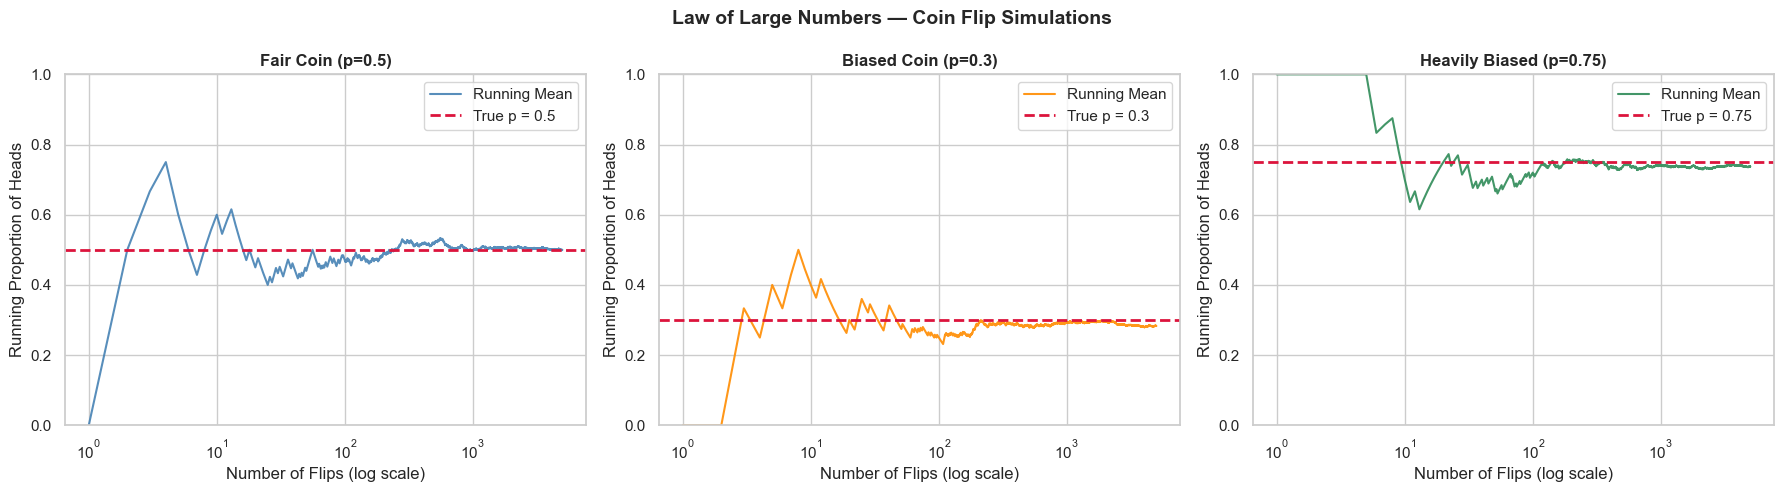


📖 Interpretation:
   • With very few flips the running mean fluctuates wildly.
   • As the number of flips grows (→ 5,000), the running mean
     converges to the true probability p for all coin biases.
   • This demonstrates the Law of Large Numbers in action:
     "More data → closer to the truth."



In [37]:
np.random.seed(42)
max_flips = 5000

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
configs = [
    {'p': 0.5,  'label': 'Fair Coin (p=0.5)',       'color': 'steelblue'},
    {'p': 0.3,  'label': 'Biased Coin (p=0.3)',     'color': 'darkorange'},
    {'p': 0.75, 'label': 'Heavily Biased (p=0.75)', 'color': 'seagreen'},
]

for ax, cfg in zip(axes, configs):
    flips = np.random.binomial(1, cfg['p'], max_flips)
    running_mean = np.cumsum(flips) / np.arange(1, max_flips + 1)

    ax.plot(np.arange(1, max_flips + 1), running_mean,
            color=cfg['color'], linewidth=1.5, alpha=0.9, label='Running Mean')
    ax.axhline(cfg['p'], color='crimson', linestyle='--', linewidth=2, label=f'True p = {cfg["p"]}')
    ax.set_xscale('log')
    ax.set_title(cfg['label'], fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of Flips (log scale)')
    ax.set_ylabel('Running Proportion of Heads')
    ax.set_ylim(0, 1)
    ax.legend()

plt.suptitle('Law of Large Numbers — Coin Flip Simulations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bonus_lln.png', bbox_inches='tight')
plt.show()

print('''
📖 Interpretation:
   • With very few flips the running mean fluctuates wildly.
   • As the number of flips grows (→ 5,000), the running mean
     converges to the true probability p for all coin biases.
   • This demonstrates the Law of Large Numbers in action:
     "More data → closer to the truth."
''')